# LOADING LIBRARIES

In [2]:
import torch
import torch.nn as nn
import numpy as np

import pandas as pd
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

# LOADING DATASET

In [5]:
import os
import torchvision

def load_imgs_as_tensor(imgs_parent_dir: str) -> torch.Tensor:
    imsge_files = list(sorted(
        Path(imgs_parent_dir).glob("*.png"),
        key=lambda filename: int(filename.name.rstrip(".png"))
    ))
    imgs = torch.empty(len(imsge_files), 256, 256, dtype=torch.uint8)
    for img_idx, image_file in enumerate(imsge_files):
        imgs[img_idx] = torchvision.io.decode_image(image_file)[0]
    return imgs

labels_df: pd.DataFrame = pd.read_csv('dataset/raw/y-train.csv', index_col=0).T.iloc[:800]
labeled_img_mask = labels_df.nunique(axis=1).gt(1).values
labels_df = labels_df.loc[labeled_img_mask]

x_train = (
    load_imgs_as_tensor("dataset/raw/x-train")
    [:800]
    [labeled_img_mask]
    .type(torch.float32)
    .reshape(-1, 1, 256,256)
)
x_test = (
    load_imgs_as_tensor("dataset/raw/x-test")
    .type(torch.float32)
    .reshape(-1, 1, 256,256)
)
y_train = (
    torch.from_numpy(
        labels_df
        .astype("float64")
        .values
    )
    .reshape(-1, 256,256)
)

Our dataset images shape is torch.Size([759, 1, 256, 256])
Our dataset labels shape is torch.Size([759, 256, 256])
sampole mean 2.84161376953125


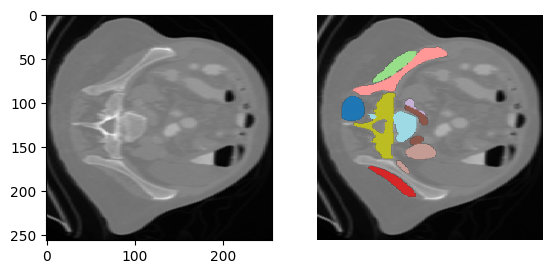

In [6]:
# Here is a function to display side by side a slide and a segmented mask
def plot_slice_seg(slice_image, seg):
    fig, axes = plt.subplots(1, 2)
    axes[0].imshow(slice_image, cmap="gray")
    axes[1].imshow(slice_image, cmap="gray")
    seg_masked = np.ma.masked_where(seg.reshape((256,256)) == 0, (seg.reshape((256,256))))
    axes[1].imshow(seg_masked, cmap="tab20")
    plt.axis("off")
    plt.show()

print(f"Our dataset images shape is {x_train.shape}")
print(f"Our dataset labels shape is {y_train.shape}")
SAMPLE_IDX = 5
print(f"sampole mean {y_train[SAMPLE_IDX].squeeze().mean()}")
plot_slice_seg(x_train[SAMPLE_IDX].squeeze(), y_train[SAMPLE_IDX].squeeze().to(dtype=torch.float32))

In [7]:
def standardize_dataset(dataset: np.ndarray | torch.Tensor):
    mean, std = dataset.mean(), dataset.std()
    return (dataset - mean) / (std + 1e-8)

x_train = standardize_dataset(x_train)
x_test = standardize_dataset(x_test)

In [8]:
## Split for train and test data
X_train, X_valid, y_train, y_valid = train_test_split(
    x_train,
    y_train,
    test_size=0.02,
    random_state=0,
)
assert len(X_train) == len(y_train)
assert len(X_valid) == len(y_valid)
print(f"Number of training images {len(X_train)}")
print(f"Number of validation images {len(X_valid)}")

Number of training images 743
Number of validation images 16


In [9]:
from torch.utils.data import TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 4
train_ds = TensorDataset(
    X_train.cuda(),
    y_train.to(device=device, dtype=torch.long),
)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

valid_ds = TensorDataset(
    X_valid.cuda(),
    y_valid.to(device=device, dtype=torch.long),
)
valid_batch_size = int(np.clip(BATCH_SIZE * 2, a_min=1, a_max=64))
valid_loader = DataLoader(valid_ds, batch_size=valid_batch_size, shuffle=False)

dir_checkpoint = Path('./checkpoints/')

# Swin -UNET

In [10]:
import warnings
import numpy as np
import pandas as pd
from pathlib import Path

def dice_pandas(y_true_df: pd.DataFrame, y_pred_df: pd.DataFrame) -> float:
    """
    Fully vectorized computation of the average Dice over samples and classes (skip background=0).
    This removes the Python loop over samples by using boolean broadcasting.
    Note: memory usage ~ O(S * P * K) where S = n_samples, P = pixels per sample, K = NUM_CLASSES.
    """
    # transpose to get shape (n_samples, n_pixels)
    y_true = y_true_df.T.values  # shape (S, P)
    y_pred = y_pred_df.T.values  # shape (S, P)

    if y_true.shape != y_pred.shape:
        raise ValueError("y_true and y_pred must have the same shape after transpose.")

    S, P = y_true.shape
    classes = np.arange(1, NUM_CLASSES + 1)  # skip background 0, shape (K,)

    # boolean one-hot along classes: shape (S, P, K)
    gt_mask = (y_true[..., None] == classes)     # True where pixel belongs to class c in GT
    pred_mask = (y_pred[..., None] == classes)   # True where pixel belongs to class c in pred

    # intersection and sums per (sample, class)
    intersection = np.sum(pred_mask & gt_mask, axis=1).astype(np.float64)  # (S, K)
    sum_pred = np.sum(pred_mask, axis=1).astype(np.float64)               # (S, K)
    sum_gt   = np.sum(gt_mask, axis=1).astype(np.float64)                 # (S, K)

    denom = sum_pred + sum_gt  # (S, K)

    # dice per sample per class; where denom==0 => np.nan
    with np.errstate(divide='ignore', invalid='ignore'):
        dice_spc = np.where(denom == 0, np.nan, 2.0 * intersection / denom)  # (S, K)

    # average over samples (ignoring NaNs), then average over classes
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        cls_dices = np.nanmean(dice_spc, axis=0)  # (K,)

    return float(np.nanmean(cls_dices))


def dice_pandas_einsum(y_true_df: pd.DataFrame, y_pred_df: pd.DataFrame) -> float:
    """
    Memory-friendly variant:
    - No Python loop over samples (S) — uses einsum to compute per-sample intersections.
    - Loops only over classes (K loops). Good when S*P is large but K is moderate.
    """
    y_true = y_true_df.T.values  # (S, P)
    y_pred = y_pred_df.T.values  # (S, P)

    if y_true.shape != y_pred.shape:
        raise ValueError("y_true and y_pred must have the same shape after transpose.")

    S, P = y_true.shape
    K = NUM_CLASSES
    dices_per_class = np.empty((S, K), dtype=np.float64)

    for idx, c in enumerate(range(1, K + 1)):  # loop over classes only (K iterations)
        pred_mask = (y_pred == c)  # (S, P) boolean
        gt_mask   = (y_true == c)  # (S, P) boolean

        # intersection per sample: einsum over pixel dim
        intersection = np.einsum('sp,sp->s', pred_mask.astype(np.int64), gt_mask.astype(np.int64)).astype(np.float64)  # (S,)
        sum_pred = pred_mask.sum(axis=1).astype(np.float64)  # (S,)
        sum_gt   = gt_mask.sum(axis=1).astype(np.float64)    # (S,)
        denom = sum_pred + sum_gt

        # dice per sample for this class
        with np.errstate(divide='ignore', invalid='ignore'):
            dices_per_class[:, idx] = np.where(denom == 0, np.nan, 2.0 * intersection / denom)

    # average over samples then classes (ignore NaNs)
    cls_dices = np.nanmean(dices_per_class, axis=0)  # (K,)
    return float(np.nanmean(cls_dices))


In [11]:
def dice_loss(pred, target, smooth=1e-7):
    pred = torch.softmax(pred, dim=1)
    target_onehot = torch.nn.functional.one_hot(target, num_classes=pred.shape[1]).permute(0, 3, 1, 2)
    intersection = (pred * target_onehot).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + target_onehot.sum(dim=(2, 3))
    dice = (2. * intersection + smooth) / (union + smooth)
    return 1 - dice.mean()

In [12]:
from time import time
from torch import Tensor
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

def train_unet(
        model: nn.Module,
        device: torch.device,
        train_loader: DataLoader,
        valid_loader: DataLoader,
        labels_weights: Tensor,
        nb_epochs: int,
        save_checkpoint: bool=True
    ):

    torch.backends.cuda.matmul.fp32_precision = 'ieee'
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    labels_weights = labels_weights.to(device)

    criterion = nn.CrossEntropyLoss(weight=labels_weights)
    model = model.to(device)

    for epoch in tqdm(range(nb_epochs)):

        model.train()
        train_loss = 0

        for (image, mask) in train_loader:
            image = image.to(device=device)
            mask = mask.to(device=device)
            optimizer.zero_grad()
            with torch.autocast(device_type=device.type, dtype=torch.bfloat16):
                output = model(image)
                loss_ce = criterion(output, mask)
                loss_dice = dice_loss(output, mask)
                loss = 0.5 * loss_dice + 0.5 * loss_ce
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            train_loss += loss.item()

        with torch.no_grad() :
            model.eval()
            test_loss = 0
            predictions = []
            true_masks = []

            for (image, mask) in valid_loader:
                true_masks.append(mask.cpu().numpy().squeeze())
                image = image.to(device=device)
                mask = mask.to(device=device)

                output = model(image)

                pred = torch.argmax(output, dim=1)
                predictions.append(pred.squeeze().cpu().numpy())

                loss_ce = criterion(output, mask)
                loss_dice = dice_loss(output, mask)
                loss = 0.5 * loss_dice + 0.5 * loss_ce

                test_loss += loss.item()

            predictions = pd.DataFrame(np.array(predictions).reshape((-1, 256*256)))
            valid = pd.DataFrame(np.array(true_masks).reshape((-1, 256*256)))
            score = dice_pandas(valid, predictions)

        print(f"Epoch : {epoch} \t Training Loss : {train_loss / len(train_loader):.3f} \t Test Loss : {test_loss / len(valid_loader):.3f} \t Score: {score:.3f}")

        if save_checkpoint:
            start_save_time = time()
            Path(dir_checkpoint).mkdir(parents=True, exist_ok=True)
            state_dict = model.state_dict()
            torch.save(state_dict, str(dir_checkpoint / 'checkpoint_epoch{}.pth'.format(epoch)))

In [13]:
import json

file_name = "./dataset/raw/annotated_labels.json"
with open(file_name, 'r') as file :
    data = json.load(file)

flattened_data = []
for i in data :
    flattened_data += i

labels, labels_count = np.unique(flattened_data, return_counts=True)
labels_weights = labels_count / np.sum(labels_count)

# adding the background
labels_weights = np.insert(labels_weights, 0, 0.0001)
class_weights = torch.from_numpy(labels_weights).type(torch.float32)

In [ ]:
from monai.networks.nets import SwinUNETR

NUM_CLASSES = 55
model = SwinUNETR(
    in_channels=1,
    out_channels=NUM_CLASSES,
    feature_size=48,
    spatial_dims=2,
).cuda()
N_EPOCHS = 20
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

train_unet(
    model,
    device,
    train_loader,
    valid_loader,
    class_weights,
    nb_epochs=N_EPOCHS,
    save_checkpoint=True,
)

Device : cuda


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch : 0 	 Training Loss : 2.037 	 Test Loss : 1.892 	 Score: 0.016
Epoch : 1 	 Training Loss : 1.585 	 Test Loss : 1.706 	 Score: 0.030
Epoch : 2 	 Training Loss : 1.401 	 Test Loss : 1.480 	 Score: 0.034


In [ ]:
test_model = SwinUNETR(
    in_channels=1,
    out_channels=NUM_CLASSES,
    feature_size=48,
    spatial_dims=2
).cuda()
test_model.load_state_dict(torch.load(str(dir_checkpoint / f'checkpoint_epoch{N_EPOCHS - 1}.pth'), weights_only=True))
test_model = test_model.eval()

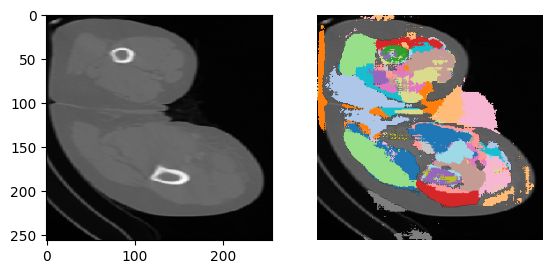

In [ ]:
# VISUAL TESTING
image_test = x_test[4]
label_test = test_model(image_test.unsqueeze(0).to(device))
pred_test = torch.argmax(label_test, dim=1)
plot_slice_seg(image_test.squeeze(), pred_test.squeeze().cpu().numpy())

In [ ]:
test_loader = DataLoader(x_test, batch_size=1, shuffle=False)

predictions = []

for image in test_loader :
    image = image.to(device=device)

    output = test_model(image)

    pred = torch.argmax(output, dim=1)
    predictions.append(pred.cpu().numpy())

predictions = np.array(predictions)
print("n unique values:", len(np.unique(predictions)))
df = pd.DataFrame(predictions.reshape((predictions.shape[0], -1))).T

df.index = [f"Pixel {i}" for i in df.index]

df.columns = [f"{col}.png" for col in df.columns]

df.to_csv("submission.csv")

n unique values: 50
